# Model Comparison

Compare the F1 scores for action name extraction, actiona argument name extraction across different LLM models and basedline cEASDRL, cEASDRL*

In [1]:
import sys
from pathlib import Path

search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    (path for path in search_roots if (path / "src/eval/read_eval.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Project root not found. Start Jupyter inside the llm-action-extraction repository.")
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    METHOD_ORDER,
    MODEL_LABELS,
    MODEL_ORDER,
    read_eval_results,
)
from utils.helpers import find_project_root, df_to_latex


BASELINES = [
    ["win2k", "cEASDRL", 0.9275, 0.925],
    ["cooking", "cEASDRL", 0.852, 0.765],
    ["wikihow", "cEASDRL", 0.7843, 0.771],
    ["win2k", "cEASDRL*", 0.8393, 0.8008],
    ["cooking", "cEASDRL*", 0.7883, 0.665],
    ["wikihow", "cEASDRL*", 0.7174, 0.686],
]

In [2]:
ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

result_df = read_eval_results(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
)

missing_models = [model for model in MODEL_ORDER if model not in set(result_df["model"].astype(str))]
if missing_models:
    print("Models missing from at least one result directory:", missing_models)

baseline_df = pd.DataFrame(
    BASELINES,
    columns=["domain", "method", "Action F1", "Argument F1"],
)

display(result_df.head(5))
display(baseline_df)

,domain,method,model,Action Precision,Action Recall,Action F1,Argument Precision,Argument Recall,Argument F1,perfect_action_argument_matches,argument_mismatch_actions,matched_action_events
0,win2k,nl2p_1,gemma3-12b,0.956747,0.829707,0.888710,0.804196,0.551228,0.654106,492,614,1106
1,win2k,nl2p_1_ablation,gemma3-12b,0.951572,0.838323,0.891365,0.813264,0.554102,0.659123,506,614,1120
2,win2k,nl2p_1_coref,gemma3-12b,0.964317,0.828721,0.891392,0.793345,0.546112,0.646912,487,621,1108
3,win2k,nl2p_1,gemma3-27b,0.945265,0.821752,0.879192,0.842541,0.552536,0.667396,490,598,1088
4,win2k,nl2p_1_ablation,gemma3-27b,0.938552,0.839608,0.886328,0.826163,0.549971,0.660351,506,609,1115


,domain,method,Action F1,Argument F1
0,win2k,cEASDRL,0.9275,0.9250
1,cooking,cEASDRL,0.8520,0.7650
2,wikihow,cEASDRL,0.7843,0.7710
3,win2k,cEASDRL*,0.8393,0.8008
4,cooking,cEASDRL*,0.7883,0.6650
5,wikihow,cEASDRL*,0.7174,0.6860


## Figure-style Comparison

- Top row: action-name F1
- Bottom row: argument-name F1

Each column is one dataset. Bars compare the three top-level NL2P strategies. Dashed horizontal baselines are repeated within each dataset panel.

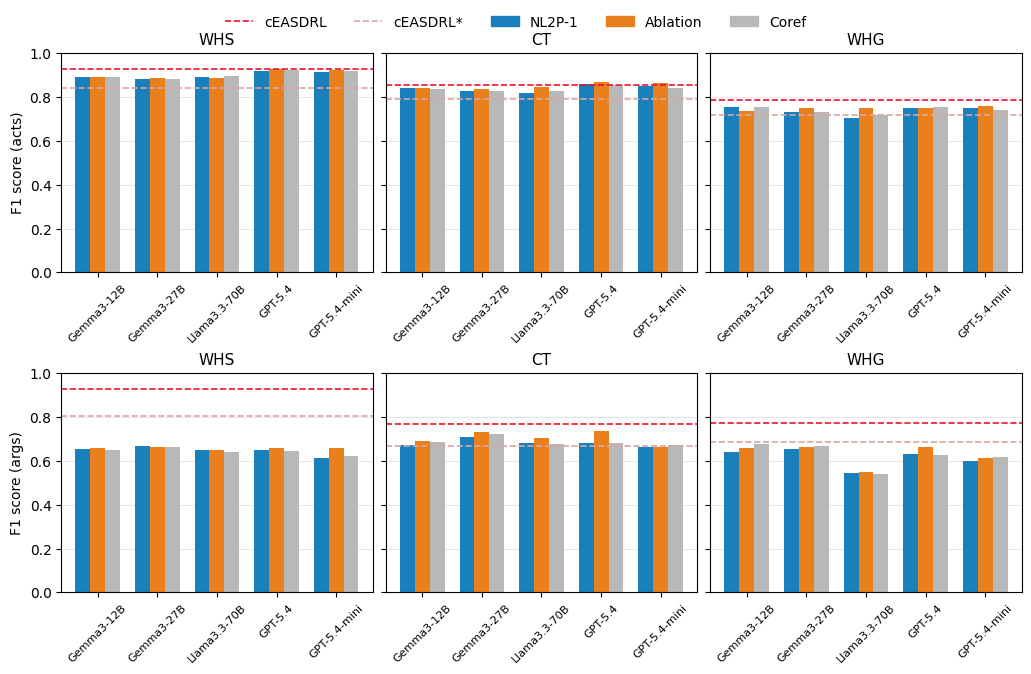

In [3]:
colors = ["#1a80bb", "#ea801c", "#b8b8b8"]
offsets = [-0.25, 0.0, 0.25]
metrics = ["Action F1", "Argument F1"]
y_labels = ["F1 score (acts)", "F1 score (args)"]
models = [model for model in MODEL_ORDER if model in set(result_df["model"].astype(str))]
model_labels = [MODEL_LABELS.get(model, model) for model in models]

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(DOMAIN_ORDER),
    figsize=(10.2, 6.4),
    sharey="row",
    constrained_layout=True,
)

x = np.arange(len(models))
width = 0.25

for row_idx, metric in enumerate(metrics):
    for col_idx, domain in enumerate(DOMAIN_ORDER):
        ax = axes[row_idx, col_idx]
        panel = result_df[result_df["domain"].astype(str) == domain]

        for method_key, color, offset in zip(METHOD_ORDER, colors, offsets):
            values = []
            for model in models:
                match = panel[
                    (panel["method"].astype(str) == method_key)
                    & (panel["model"].astype(str) == model)
                ]
                values.append(np.nan if match.empty else float(match.iloc[0][metric]))

            ax.bar(x + offset, values, width=width, color=color, label=METHOD_LABELS[method_key], edgecolor="none")

        baseline_panel = baseline_df[baseline_df["domain"] == domain]
        for baseline, color in [("cEASDRL", "#ed1131"), ("cEASDRL*", "#d8a6a6")]:
            match = baseline_panel[baseline_panel["method"] == baseline]
            if not match.empty:
                ax.axhline(float(match.iloc[0][metric]), color=color, linestyle="--", linewidth=1.2)

        ax.set_title(DOMAIN_LABELS[domain], fontsize=11)
        ax.set_ylim(0.0, 1.0)
        ax.set_xticks(x)
        ax.set_xticklabels(model_labels, rotation=45, fontsize=8)
        ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
        if col_idx == 0:
            ax.set_ylabel(y_labels[row_idx])

legend_handles = [
    plt.Line2D([0], [0], color="#ed1131", linestyle="--", linewidth=1.2, label="cEASDRL"),
    plt.Line2D([0], [0], color="#d8a6a6", linestyle="--", linewidth=1.2, label="cEASDRL*"),
]
for method_key, color in zip(METHOD_ORDER, colors):
    legend_handles.append(plt.Rectangle((0, 0), 1, 1, color=color, label=METHOD_LABELS[method_key]))

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=5,
    frameon=False,
)
plt.show()


## Paper Table

This table is convenient when drafting the caption or checking exact values.

In [4]:
table_source = result_df.assign(
    domain=result_df["domain"].astype(str).map(DOMAIN_LABELS),
    method=result_df["method"].astype(str).map(METHOD_LABELS),
    model_label=result_df["model"].astype(str).map(MODEL_LABELS).fillna(result_df["model"].astype(str)),
)

table_df = table_source.pivot_table(
    index=["method", "model_label"],
    columns="domain",
    values=["Action F1", "Argument F1"],
    aggfunc="first",
    observed=False,
)

baseline_table = baseline_df.assign(
    domain=baseline_df["domain"].map(DOMAIN_LABELS),
    model_label="baseline",
).pivot_table(
    index=["method", "model_label"],
    columns="domain",
    values=["Action F1", "Argument F1"],
    aggfunc="first",
    observed=False,
)

table = pd.concat([baseline_table, table_df]).round(4)
display(table)
print(df_to_latex(table))

Action F1                 Argument F1                
domain                       CT     WHG     WHS          CT     WHG     WHS
method   model_label                                                       
cEASDRL  baseline        0.8520  0.7843  0.9275      0.7650  0.7710  0.9250
cEASDRL* baseline        0.7883  0.7174  0.8393      0.6650  0.6860  0.8008
Ablation GPT-5.4         0.8654  0.7472  0.9238      0.7331  0.6604  0.6578
         GPT-5.4-mini    0.8601  0.7591  0.9191      0.6637  0.6110  0.6565
         Gemma3-12B      0.8391  0.7338  0.8914      0.6879  0.6572  0.6591
         Gemma3-27B      0.8361  0.7486  0.8863      0.7294  0.6632  0.6604
         Llama3.3-70B    0.8445  0.7488  0.8852      0.7016  0.5474  0.6471
Coref    GPT-5.4         0.8538  0.7517  0.9190      0.6804  0.6258  0.6422
         GPT-5.4-mini    0.8406  0.7397  0.9183      0.6695  0.6153  0.6201
         Gemma3-12B      0.8354  0.7527  0.8914      0.6868  0.6744  0.6469
         Gemma3-27B      0.8268  0.7288  0.8795      0.7220  0.6669  0.6615
         Llama3.3-70B    0.8243  0.7185  0.8933      0.6753  0.5370  0.6410
NL2P-1   GPT-5.4         0.8583  0.7473  0.9149      0.6822  0.6293  0.6495
         GPT-5.4-mini    0.8504  0.7473  0.9102      0.6609  0.5964  0.6132
         Gemma3-12B      0.8402  0.7521  0.8887      0.6690  0.6404  0.6541
         Gemma3-27B      0.8271  0.7309  0.8792      0.7051  0.6513  0.6674
         Llama3.3-70B    0.8162  0.7016  0.8891      0.6816  0.5437  0.6470

\begin{tabular}{llrrrrrr}
 &  & \multicolumn{3}{r}{Action F1} & \multicolumn{3}{r}{Argument F1} \\
 & domain & CT & WHG & WHS & CT & WHG & WHS \\
method & model_label &  &  &  &  &  &  \\
cEASDRL & baseline & 0.852000 & 0.784300 & 0.927500 & 0.765000 & 0.771000 & 0.925000 \\
cEASDRL* & baseline & 0.788300 & 0.717400 & 0.839300 & 0.665000 & 0.686000 & 0.800800 \\
\multirow[c]{5}{*}{Ablation} & GPT-5.4 & 0.865400 & 0.747200 & 0.923800 & 0.733100 & 0.660400 & 0.657800 \\
 & GPT-5.4-mini & 0.860100 & 0.759100 & 0.919100 & 0.663700 & 0.611000 & 0.656500 \\
 & Gemma3-12B & 0.839100 & 0.733800 & 0.891400 & 0.687900 & 0.657200 & 0.659100 \\
 & Gemma3-27B & 0.836100 & 0.748600 & 0.886300 & 0.729400 & 0.663200 & 0.660400 \\
 & Llama3.3-70B & 0.844500 & 0.748800 & 0.885200 & 0.701600 & 0.547400 & 0.647100 \\
\multirow[c]{5}{*}{Coref} & GPT-5.4 & 0.853800 & 0.751700 & 0.919000 & 0.680400 & 0.625800 & 0.642200 \\
 & GPT-5.4-mini & 0.840600 & 0.739700 & 0.918300 & 0.669500 & 0.615300 & 0.620100 \\
 